# Sequential CTTA: Messidor → IDRiD → APTOS (RETFound-DINOv2)

Protocol:
1. Load RETFound pretrained weights
2. Evaluate baseline on source domain (Messidor-2)
3. Adapt to target domain (IDRiD) - adaptation mode
4. Adapt to target domain (APTOS) - adaptation mode
5. Evaluate on ALL previous domains - TEST mode

This tests if Messidor as source provides useful initialization.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/cotta/messidor_idrid_aptos.yaml')

print('Protocol: Sequential CTTA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential CTTA
Source: messidor2
Targets: ['idrid', 'aptos2019']
Method: cotta
Output: ./outputs/sequential_cotta/messidor_idrid_aptos/
HF_TOKEN set


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 17:25:11,352 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: messidor2 -> idrid -> aptos2019
2026-08-05 17:25:15,958 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/YukunZhou/RETFound_dinov2_meh/resolve/main/RETFound_dinov2_meh.pth "HTTP/1.1 302 Found"
2026-08-05 17:25:17,082 - src.models.retfound - INFO - Extracted state_dict from DINOv2 'teacher' key
2026-08-05 17:25:17,090 - src.models.retfound - INFO - Stripped 'backbone.' prefix from 359 state dict keys
2026-08-05 17:25:17,091 - src.models.retfound - INFO - RETFound checkpoint cached in CPU RAM
2026-08-05 17:25:17,229 - src.models.retfound - INFO - Feature normalization ENABLED in forward() (required for prototype classifier)
2026-08-05 17:25:17,982 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-05 17:26:39,704 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=100.0
2026-08-05 17:26:39,708 - src.evaluation.runner.base - INFO - Prototype

Adapting to messidor2:   0%|          | 0/22 [00:00<?, ?it/s]

2026-08-05 17:27:12,803 - src.evaluation.runner.sequential - INFO -   Adapt step 0: loss=0.2533, kl=0.1922, conf_samples=9, teacher_max_prob=0.4445


Adapting to messidor2:   5%|▍         | 1/22 [00:11<04:00, 11.44s/it, acc=0.6250, adaptations=1]

2026-08-05 17:27:23,313 - src.evaluation.runner.sequential - INFO -   Adapt step 1: loss=0.2869, kl=0.2258, conf_samples=8, teacher_max_prob=0.5026


...

Adapting to aptos2019:  96%|█████████▌| 22/23 [03:50<00:10, 10.28s/it, acc=0.4375, adaptations=22]

2026-08-05 17:37:19,910 - src.evaluation.runner.sequential - INFO -   Adapt step 22: loss=0.3476, kl=0.2859, conf_samples=6, teacher_max_prob=0.5100


Adapting to aptos2019: 100%|██████████| 23/23 [03:59<00:00, 10.42s/it, acc=0.4286, adaptations=23]

2026-08-05 17:37:20,724 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on aptos2019


2026-08-05 17:37:45,148 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.7152
2026-08-05 17:37:45,159 - src.evaluation.runner.sequential - INFO - Adaptations: 23/23
2026-08-05 17:37:45,310 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 3 seen domains after adapting to aptos2019
2026-08-05 17:37:45,312 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on messidor2 (no adaptation)
2026-08-05 17:38:06,118 - src.evaluation.runner.sequential - INFO -   QWK on messidor2: 0.7473
2026-08-05 17:38:06,120 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on idrid (no adaptation)
2026-08-05 17:38:15,437 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.6487
2026-08-05 17:38:39,970 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.7152
2026-08-05 17:38:39,972 - src.evaluation.runner.sequential - INFO - 
2026-08-05 17:38:39,973 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summar

=============== Sequential CTTA Results (CoTTA DINOv2) ===============

Source domain: messidor2
  Baseline QWK:           0.7529
  Baseline Overall Acc:   65.90%

Target domains: idrid, aptos2019

----------------------------------------------------------------------
After adapting to source messidor2 (22/22 batches):
  QWK:                  0.7387  (delta: -0.0142)
  Overall Acc:          65.62% (delta: -0.29pp)

----------------------------------------------------------------------
After adapting to idrid (7/7 batches):
  Post-adaptation QWK on idrid: 0.6477
  Post-adaptation Acc on idrid: 43.69%
  Test on messidor2:
    QWK: 0.7423  (delta vs baseline: -0.0106)
    Acc: 66.19% (delta vs baseline: +0.29pp)

----------------------------------------------------------------------
After adapting to aptos2019 (23/23 batches):
  Post-adaptation QWK on aptos2019: 0.7152
  Post-adaptation Acc on aptos2019: 51.91%
  Test on messidor2:
    QWK: 0.7473  (delta vs baseline: -0.0056)
    Acc: 67

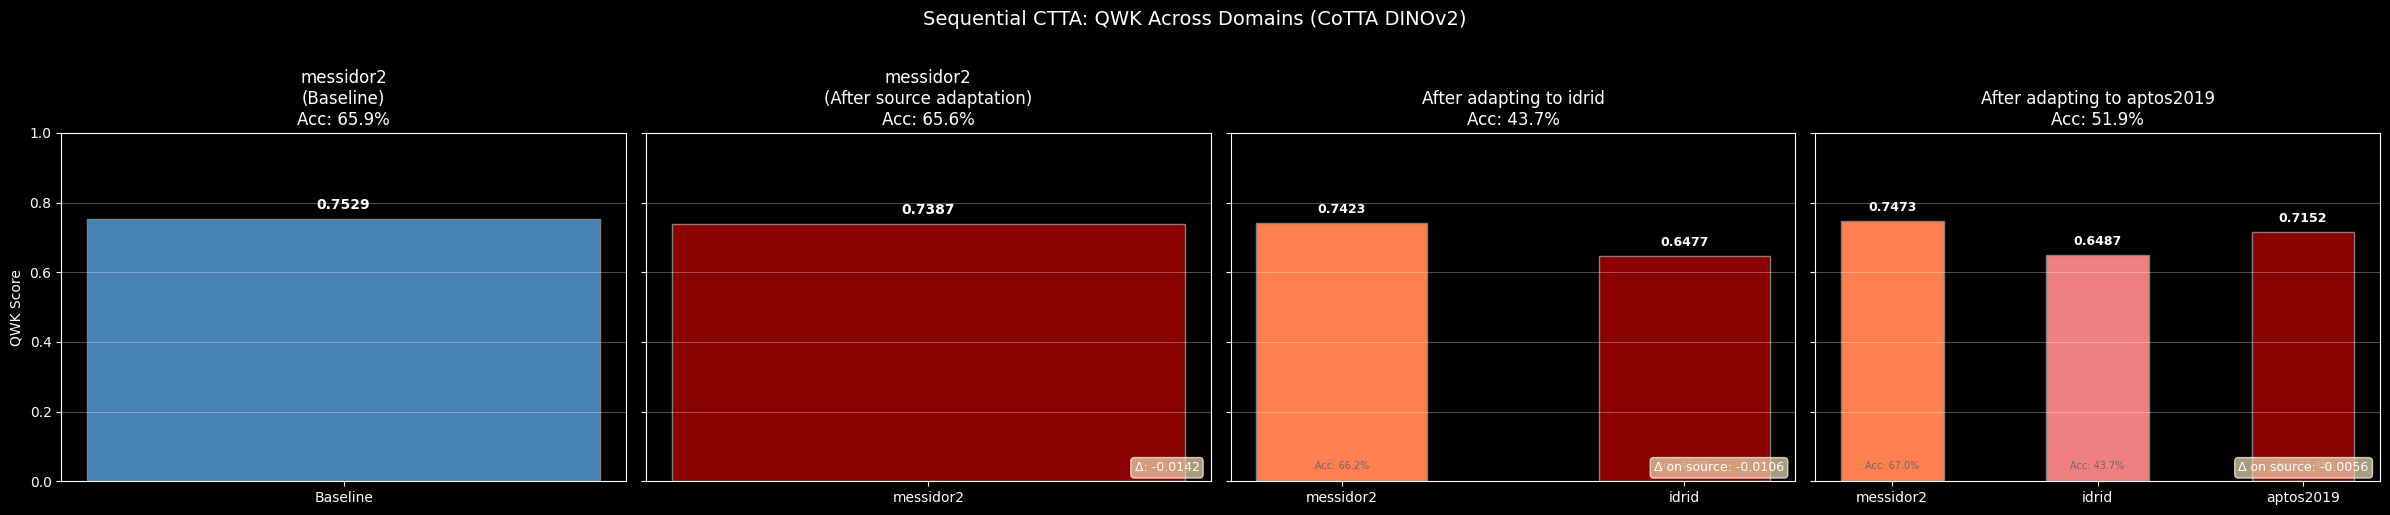

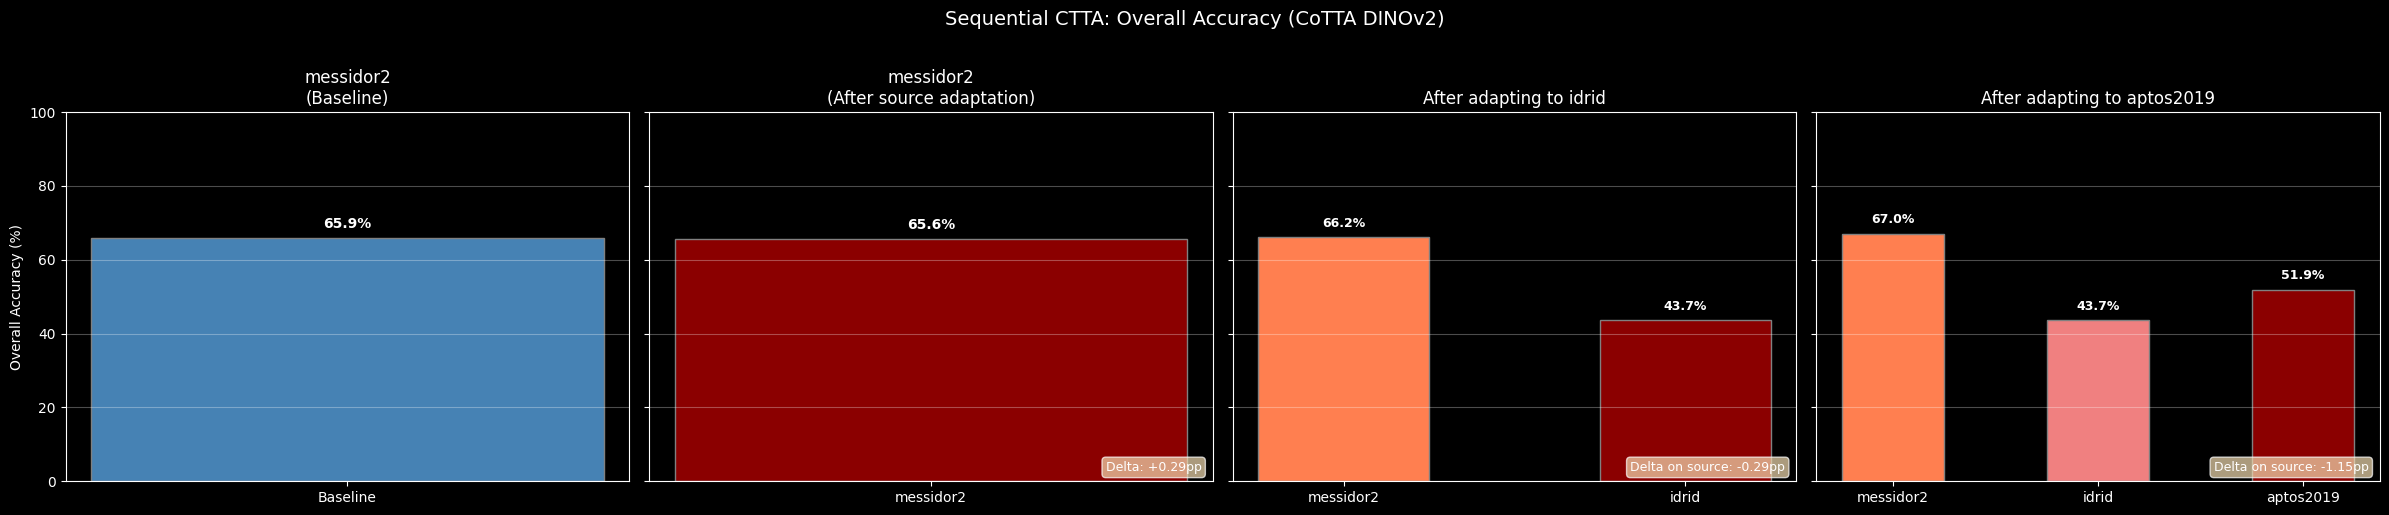

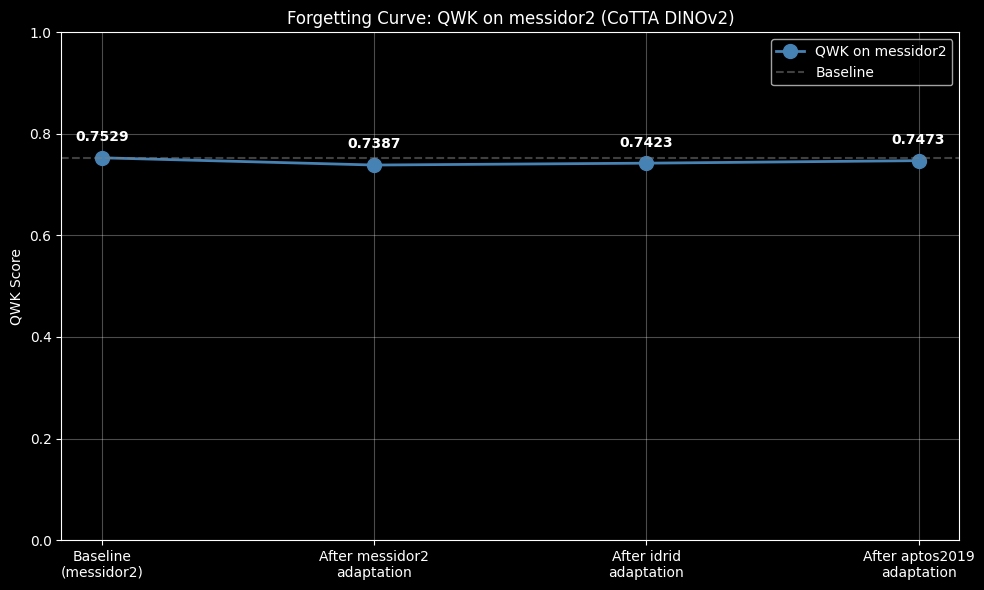

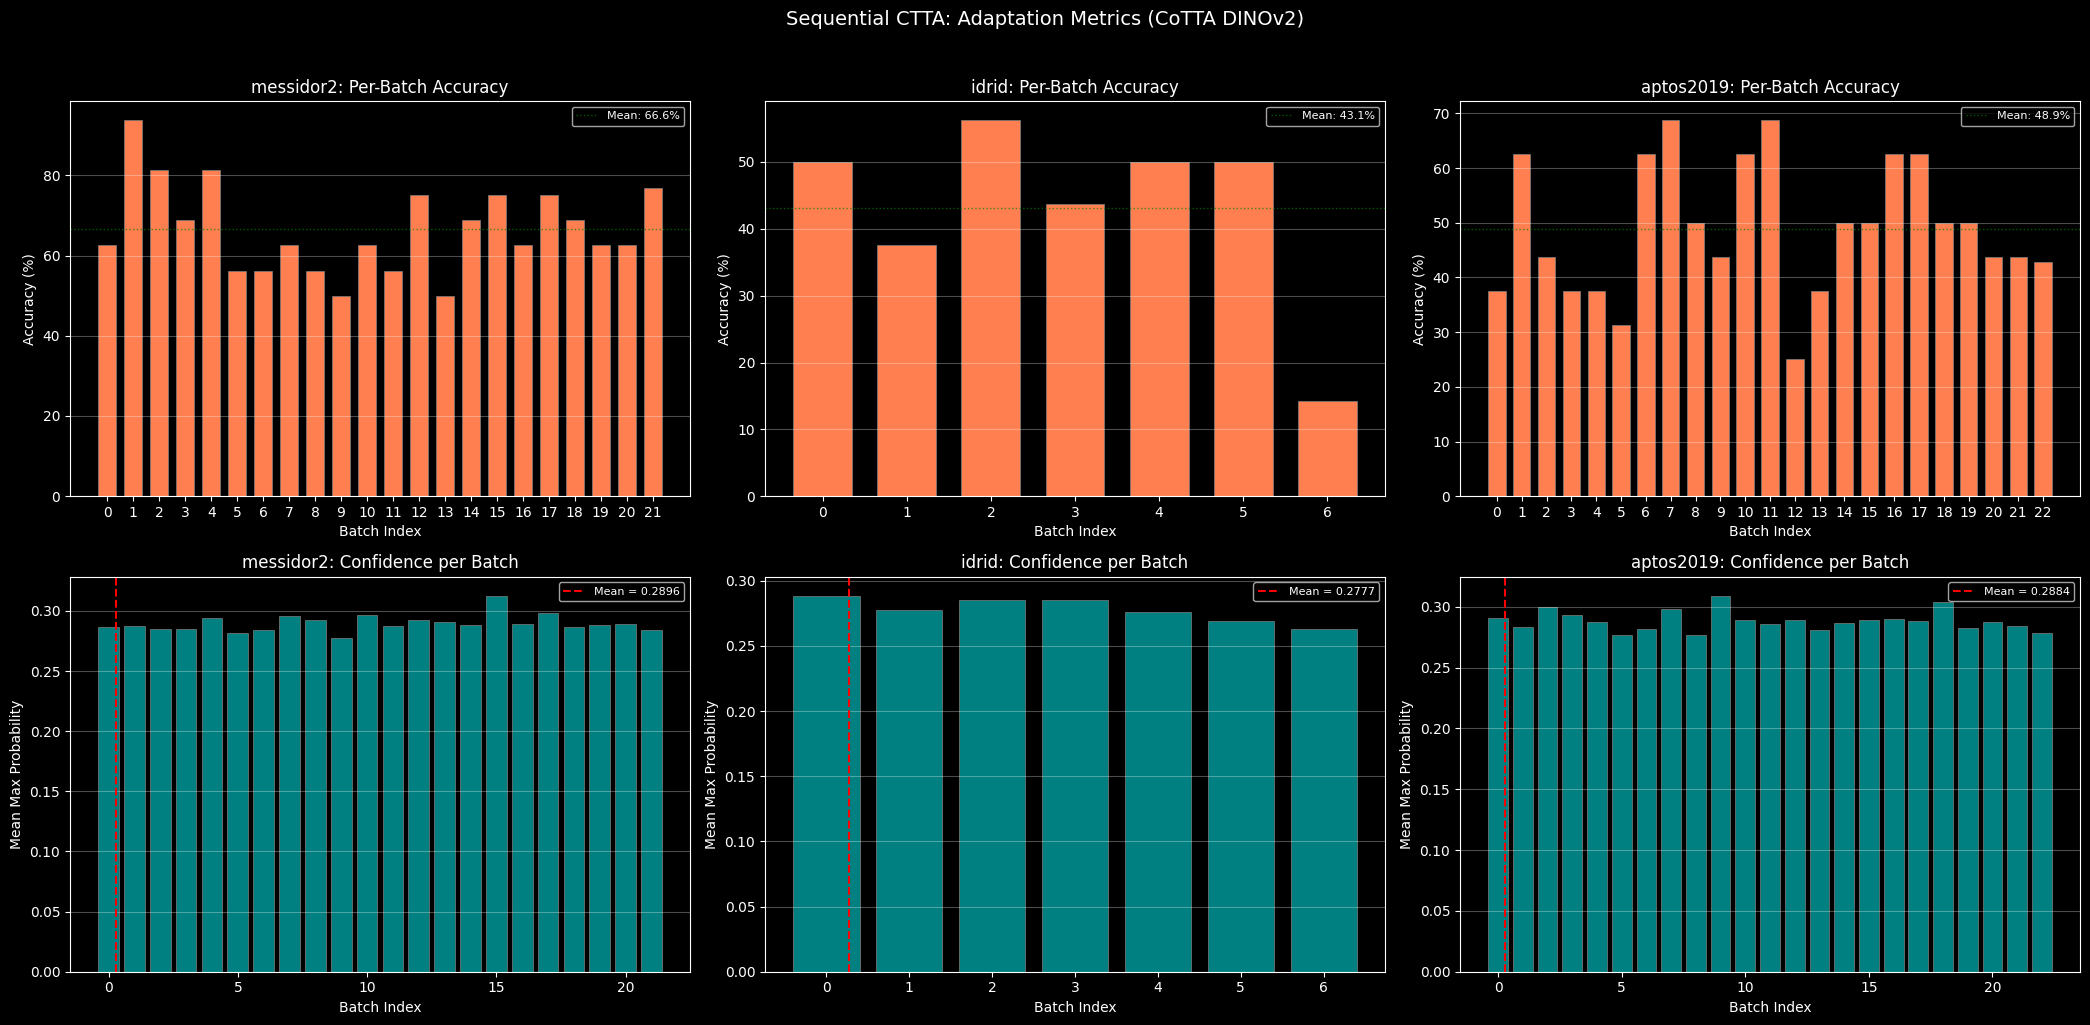

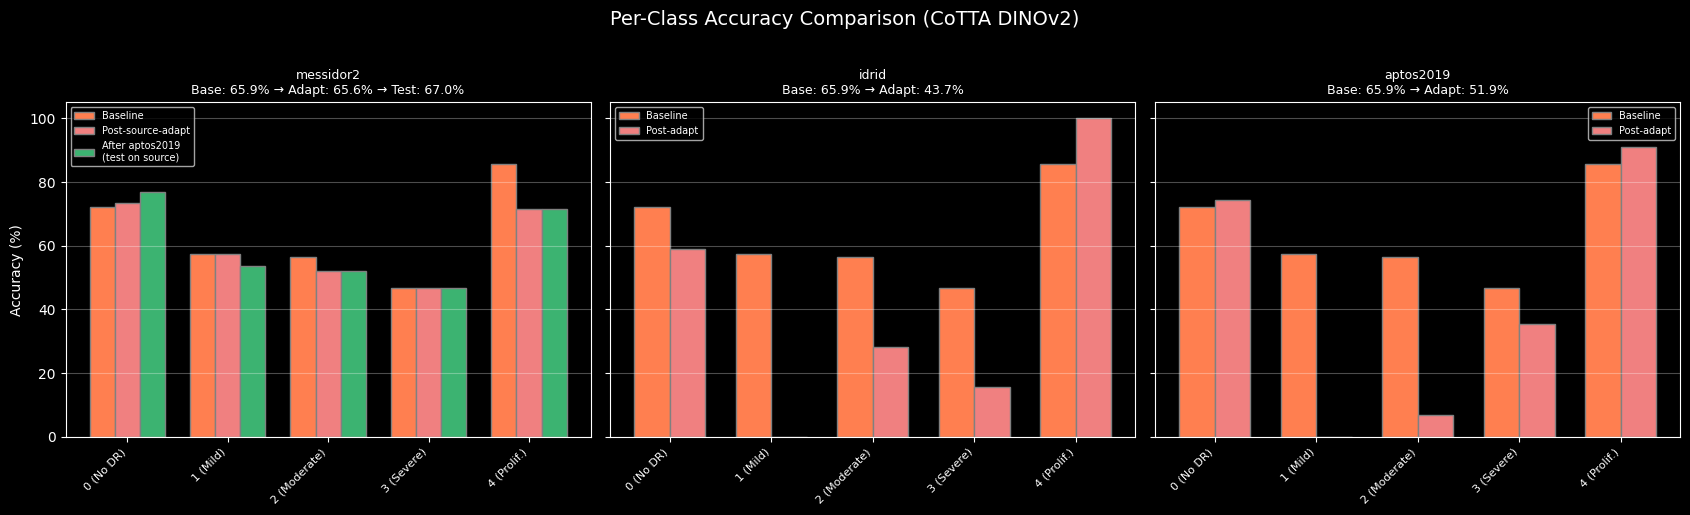

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

method_name = 'CoTTA DINOv2' if config.model.name == 'retfound' else 'CoTTA VisionFM'

print_sequential_summary(results, method_name=method_name)
plot_sequential_qwk_comparison(results, plots_dir, method_name=method_name)
plot_sequential_overall_accuracy(results, plots_dir, method_name=method_name)
plot_sequential_forgetting(results, plots_dir, method_name=method_name)
plot_sequential_adaptation_comparison(results, plots_dir, method_name=method_name)
plot_sequential_per_class_accuracy(results, plots_dir, method_name=method_name)